# Encodeur Perceptuel

Ce notebook fait suite au notebook `projection-apprentissage.ipynb`. En s'insipirant de fonctions décrites dans l'article _Encoding In Style_ ou pixel2style2pixel (pSp), nous avons amélioré le projecteur précédent.

## Architecture

- **Backbone** : ResNet-34 pré-entraîné sur ImageNet, deux derniers blocs résiduels affinés
- **Tête** : couche linéaire prédisant $18 \times 512 = 9\,216$ valeurs (un vecteur $w$ par couche de synthèse)
- **Encodage** : l'encodeur prédit un *delta* $\delta$ par rapport au visage moyen $\bar{w}$ :
  $$w_{\text{prédit}} = \bar{w} + \delta$$
  Puisqu'on initialise à zéro la dernière couche, on commence avec le visage moyen directement.

## Fonctions de perte (basée sur pSp)

| Perte | Poids | Rôle |
|---|---|---|
| MSE pixel | 1.0 | Fidélité bas niveau |
| LPIPS (VGG) | 0.8 | Similarité perceptuelle |
| Cosinus ArcFace | 0.1 | Préservation de l'identité |

## Initialisation

In [ ]:
import sys
import pickle
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().resolve().parent

STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
for p in [str(PROJECT_DIR), str(STYLEGAN2_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from stylegan2.torch_utils.misc import get_device

SEED = 42
_ = torch.manual_seed(SEED)

MODELS_DIR = PROJECT_DIR / 'models'
RESOLUTION = 1024

device = get_device()
print(f"Device: {device}")

Device: mps


## Chargement de StyleGAN2

In [4]:
with open(MODELS_DIR / 'ffhq.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
G = G.eval().requires_grad_(False)

w_avg = G.mapping.w_avg.detach().to(device)  # mean face anchor [w_dim]

## Définition et chargement de l'encodeur

L'encodeur est un ResNet-34 dont la couche finale prédit $\text{num\_ws} \times \text{w\_dim}$ valeurs. Seuls les blocs `layer3`, `layer4` et `fc` sont entraînés.

In [5]:
imagenet_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


def build_encoder(num_ws: int, w_dim: int) -> nn.Module:
    resnet = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.IMAGENET1K_V1)
    resnet.fc = nn.Linear(resnet.fc.in_features, num_ws * w_dim)
    nn.init.zeros_(resnet.fc.weight)
    nn.init.zeros_(resnet.fc.bias)
    for p in resnet.parameters():
        p.requires_grad = False
    for layer in [resnet.layer3, resnet.layer4, resnet.fc]:
        for p in layer.parameters():
            p.requires_grad = True
    return resnet


encoder = build_encoder(G.num_ws, G.w_dim).to(device)

checkpoint = torch.load(MODELS_DIR / 'perceptual_encoder.pt', map_location=device)
encoder.load_state_dict(checkpoint['model'])
_ = encoder.eval()

cfg = checkpoint.get('config', {})
print(f"Encoder loaded: epoch {checkpoint['epoch']}")

Encoder loaded: epoch 100


## Fonctions utilitaires

In [ ]:
def predict_w_plus(imgs: torch.Tensor) -> torch.Tensor:
    """imgs: [B, C, H, W] in [0,1] -> w_pred: [B, num_ws, w_dim]"""
    inp = F.interpolate(imgs, size=(224, 224), mode='bilinear', align_corners=False)
    with torch.inference_mode():
        delta = encoder(imagenet_normalize(inp))
    delta = delta.float().view(-1, G.num_ws, G.w_dim)
    return w_avg + delta  # pSp: w_pred = w_avg + delta


def synthesize_partial(ws: torch.Tensor, resolution: int) -> torch.Tensor:
    """Run StyleGAN2 synthesis up to the given resolution only."""
    synthesis = G.synthesis
    ws = ws.to(torch.float32)
    block_ws, w_idx = [], 0
    for res in synthesis.block_resolutions:
        block = getattr(synthesis, f'b{res}')
        block_ws.append(ws.narrow(1, w_idx, block.num_conv + block.num_torgb))
        w_idx += block.num_conv
    x = img = None
    for res, cur_ws in zip(synthesis.block_resolutions, block_ws):
        block = getattr(synthesis, f'b{res}')
        x, img = block(x, img, cur_ws, force_fp32=True, noise_mode='const')
        if res == resolution:
            break
    return ((img + 1.0) / 2.0).clamp(0.0, 1.0)


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Tensor HWC -> numpy, NumPy 2.x safe (avoids torch C bridge)."""
    return np.array(t.cpu().float().tolist(), dtype=np.float32)


def reconstruct(imgs: torch.Tensor) -> torch.Tensor:
    """[B,C,H,W] in [0,1] -> reconstructions [B,C,RESOLUTION,RESOLUTION] in [0,1]"""
    w_pred = predict_w_plus(imgs)
    raw = synthesize_partial(w_pred, RESOLUTION)
    return F.interpolate(raw, size=(RESOLUTION, RESOLUTION), mode='bilinear', align_corners=False)

## Reconstruction de visages synthétiques

On génère des vecteurs latents $z$ aléatoires, on synthétise les visages correspondants avec StyleGAN2, puis on les encode et re-synthétise. C'est l'évaluation **en distribution** : l'encodeur voit des images exactement sur la variété apprise par StyleGAN2.

In [8]:
N_TEST = 5
skwargs = {'noise_mode': 'const'}

with torch.inference_mode():
    z = torch.randn([N_TEST, G.z_dim], generator=torch.Generator().manual_seed(SEED)).to(device)
    w = G.mapping(z, None)
    originals = ((G.synthesis(w, **skwargs) + 1) / 2).clamp(0, 1)  # [B,C,1024,1024]

reconstructions = reconstruct(originals)

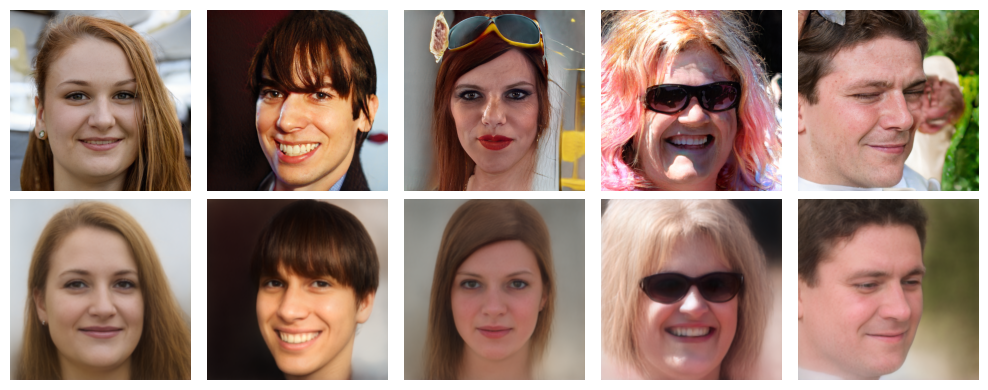

In [11]:
fig, axes = plt.subplots(2, N_TEST, figsize=(2 * N_TEST, 4), squeeze=False)

for i in range(N_TEST):
    axes[0, i].imshow(to_numpy(originals[i].permute(1, 2, 0)))
    axes[1, i].imshow(to_numpy(reconstructions[i].permute(1, 2, 0)))

for ax in axes.ravel():
    ax.set_axis_off()

fig.tight_layout()
plt.show()